# 03_tstr_v6 -- Comparativa TSTR sobre Baseline v6 (A11+A12)
## LSTM-VAE: Real Only | Synthetic Only | Real + Synthetic

El escenario real_only usa el mismo setup que baseline_v6:
A11+A12 para train y val (A11+A12 val combinado).
La evaluacion de ataques siempre es sobre A12 completo.


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

# ── Datasets ──────────────────────────────────────────────────────────────────
# A11 (Feb 2026) -- solo datos normales, 2 dias de operacion
A11_DIR        = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A11_OTDataset_Feb_26'
RAW_CSV_A11_D1 = A11_DIR / 'SWaT.A10_OTDataset_19-Feb-2026_0930_1735.csv'
RAW_CSV_A11_D2 = A11_DIR / 'SWaT.A10_OTDataset_20-Feb-2026_0905_1710.csv'

# A12 (Mar 2026) -- datos normales + ataques etiquetados
RAW_CSV_A12    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'

# ── Modelos ────────────────────────────────────────────────────────────────────
# Columnas e hiperparametros del Optuna LSTM-VAE
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
# Directorio de salida de este detector
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_baseline_v6'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('A11 Day1:', RAW_CSV_A11_D1.exists())
print('A11 Day2:', RAW_CSV_A11_D2.exists())
print('A12 CSV :', RAW_CSV_A12.exists())
print('Optuna  :', OPTUNA_CFG.exists())
print('Save dir:', SAVE_DIR)

SYNTH_DIR  = PROJECT_ROOT / 'models' / 'timegan'   / 'lstm_vae_a12_baseline_v1_v18'
TSTR_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_tstr_v6'
TSTR_DIR.mkdir(parents=True, exist_ok=True)
print('SYNTH_DIR   :', SYNTH_DIR.exists())
print('TSTR_DIR    :', TSTR_DIR)


A11 Day1: True
A11 Day2: True
A12 CSV : True
Optuna  : True
Save dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v6
SYNTH_DIR   : True
TSTR_DIR    : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr_v6


## 2. Hiperparametros (identicos a baseline v6)

In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
bp              = optuna_cfg['best_params']

# Arquitectura (desde Optuna)
WINDOW_SIZE = 60                # Fijo -- igual que TimeGAN v18
STRIDE      = 5                 # = TIMEGAN_STRIDE (reemplaza stride del Optuna)
HIDDEN_SIZE = 256       # v4: 192->256, mas capacidad para 10k ventanas
NUM_LAYERS  = int(bp['num_layers'])
LATENT_DIM  = 128       # v4: 96->128, bottleneck menos agresivo
DISC_HIDDEN = int(optuna_cfg['disc_hidden'])
BETA        = float(bp['beta'])
ALPHA       = float(bp['alpha'])
DROPOUT     = float(bp['dropout'])
LR          = float(bp['lr'])
BATCH_SIZE  = int(bp['batch_size'])

# Pipeline
CLIP_VAL    = float(optuna_cfg['clip_val'])
WARMUP      = 120               # segundos de warmup por sesion
MAX_EPOCHS  = 150
PATIENCE    = 20

# Protocolo de evaluacion definitivo
EXCLUDED_IDS = [1.0, 2.0]       # Ataques sigilosos indetectables
CONSEC_K     = 13                # Filtro de ventanas consecutivas

print(f'Arquitectura : hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM}')
print(f'Entrenamiento: beta={BETA:.4f} | alpha={ALPHA:.4f} | lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'Pipeline     : window={WINDOW_SIZE} | stride={STRIDE} | clip={CLIP_VAL} | warmup={WARMUP}s')
print(f'Evaluacion   : excl={EXCLUDED_IDS} | k={CONSEC_K}')
print(f'Columnas     : {len(continuous_cols)} continuas | {len(discrete_cols)} discretas')


Arquitectura : hidden=256 | layers=1 | latent=128
Entrenamiento: beta=0.0161 | alpha=0.8891 | lr=1.07e-04 | batch=64
Pipeline     : window=60 | stride=5 | clip=5.0 | warmup=120s
Evaluacion   : excl=[1.0, 2.0] | k=13
Columnas     : 31 continuas | 31 discretas


## 3. Carga sesiones A11+A12 (identico a baseline v6)

In [5]:
all_sensor_cols = feature_cols  # = continuous_cols + discrete_cols

def load_normal_session(path, all_normal=False):
    """Carga CSV de SWaT, limpia tipos mixtos y retorna solo filas normales.

    Args:
        path      : ruta al CSV.
        all_normal: True para A11 (sin columnas de ataque, todo es normal).
                    False para A12 (tiene attack_label; se filtra ==0).
    Returns:
        DataFrame con t_stamp + all_sensor_cols, solo filas normales.
    """
    df = pd.read_csv(path, low_memory=False)
    df['t_stamp'] = pd.to_datetime(df['t_stamp'], errors='coerce')
    df = df.sort_values('t_stamp').reset_index(drop=True)
    for col in all_sensor_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('Bad Input', np.nan), errors='coerce')
    if all_normal:
        df['attack_label'] = 0
    else:
        df['attack_label'] = pd.to_numeric(df['attack_label'], errors='coerce').fillna(0).astype(int)
    df_normal = df[df['attack_label'] == 0][['t_stamp'] + all_sensor_cols].copy()
    return df_normal.reset_index(drop=True)

# Cargar las 3 sesiones y aplicar warmup individual
print('Cargando sesiones...')
sessions_raw = {
    'a11_d1': load_normal_session(RAW_CSV_A11_D1, all_normal=True),
    'a11_d2': load_normal_session(RAW_CSV_A11_D2, all_normal=True),
    'a12'   : load_normal_session(RAW_CSV_A12,    all_normal=False),
}

sessions_normal = {}
for name, df_s in sessions_raw.items():
    t0   = df_s['t_stamp'].min()
    df_w = df_s[df_s['t_stamp'] >= t0 + pd.Timedelta(seconds=WARMUP)].copy().reset_index(drop=True)
    sessions_normal[name] = df_w
    print(f'  {name}: {len(df_w):,} filas | {df_w["t_stamp"].min()} -> {df_w["t_stamp"].max()}')

total = sum(len(v) for v in sessions_normal.values())
print(f'\nTotal normal (3 sesiones): {total:,}')
print(f'  A11 d1+d2: {len(sessions_normal["a11_d1"])+len(sessions_normal["a11_d2"]):,}')
print(f'  A12:       {len(sessions_normal["a12"]):,}')


Cargando sesiones...
  a11_d1: 29,040 filas | 2026-02-19 09:32:00 -> 2026-02-19 17:35:59
  a11_d2: 29,040 filas | 2026-02-20 09:07:00 -> 2026-02-20 17:10:59
  a12: 25,620 filas | 2026-03-11 09:02:00 -> 2026-03-11 17:00:59

Total normal (3 sesiones): 83,700
  A11 d1+d2: 58,080
  A12:       25,620


In [6]:
# Split 60/20/20 dentro de cada sesion por separado
session_splits = {}
for name, df_s in sessions_normal.items():
    n = len(df_s)
    t1, t2 = int(n*0.60), int(n*0.80)
    session_splits[name] = {
        'train': df_s.iloc[:t1].copy().reset_index(drop=True),
        'val'  : df_s.iloc[t1:t2].copy().reset_index(drop=True),
        'test' : df_s.iloc[t2:].copy().reset_index(drop=True),
    }
    print(f'{name}: train={t1:,} | val={t2-t1:,} | test={n-t2:,}')

# Train = las 3 sesiones concatenadas
df_train = pd.concat([session_splits[k]['train'] for k in session_splits],
                     ignore_index=True)
# Val / Test = SOLO A12
df_val   = session_splits['a12']['val'].copy()
df_test  = session_splits['a12']['test'].copy()

print(f'\nTrain combinado (3 sesiones): {len(df_train):,}')
print(f'Val   (solo A12)            : {len(df_val):,}')
print(f'Test  (solo A12)            : {len(df_test):,}')

# Imputar NaN con moda del train de A12 (dominio objetivo)
# Se usa A12 como referencia para que el detector opere en el espacio A12.
modes_train = session_splits['a12']['train'][all_sensor_cols].mode().iloc[0]
for df_ in [df_train, df_val, df_test]:
    df_[all_sensor_cols] = df_[all_sensor_cols].fillna(modes_train)
for name in session_splits:
    for split in ['train','val','test']:
        session_splits[name][split][all_sensor_cols] = \
            session_splits[name][split][all_sensor_cols].fillna(modes_train)

print(f'NaN tras imputacion: {df_train[all_sensor_cols].isna().sum().sum()}')


a11_d1: train=17,424 | val=5,808 | test=5,808
a11_d2: train=17,424 | val=5,808 | test=5,808
a12: train=15,372 | val=5,124 | test=5,124

Train combinado (3 sesiones): 50,220
Val   (solo A12)            : 5,124
Test  (solo A12)            : 5,124
NaN tras imputacion: 0


## 4. Escalado (identico a baseline v6 -- scaler A12)

In [7]:
# v6 FIX: construir val combinado (A11_val + A12_val) POR SESION
# para que early stopping mida la distribucion de entrenamiento
val_dfs = []
for name in session_splits:
    df_sv = session_splits[name]['val'].copy()
    df_sv[all_sensor_cols] = df_sv[all_sensor_cols].fillna(modes_train)
    val_dfs.append(df_sv)
df_val_combined = pd.concat(val_dfs, ignore_index=True)
print(f'Val combinado (A11+A12): {len(df_val_combined):,} filas')

# Scaler y disc_max fiteados SOLO en A12 train (dominio objetivo)
df_a12_train = session_splits['a12']['train']

scaler_cont = StandardScaler()
scaler_cont.fit(df_a12_train[continuous_cols].values)
disc_max = df_a12_train[discrete_cols].max().replace(0, 1)

print(f'Scaler fiteado en A12 train: {len(df_a12_train):,} filas')
print(f'  Media cont (primeras 3): {scaler_cont.mean_[:3].round(4)}')

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values), -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)   # A11+A12 combinado, en espacio A12
df_val_sc   = scale_df(df_val_combined)  # v6: A11_val + A12_val
df_test_sc  = scale_df(df_test)

# Por sesion para construccion de ventanas
session_train_sc = {name: scale_df(session_splits[name]['train'])
                    for name in session_splits}

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

# Verificar que A11 escala correctamente en el espacio A12
rng_a12 = df_train_sc[continuous_cols].values
rng_a11 = np.vstack([
    session_train_sc['a11_d1'][continuous_cols].values,
    session_train_sc['a11_d2'][continuous_cols].values,
])
print(f'\nRango cont A12 train escalado: [{rng_a12.min():.2f}, {rng_a12.max():.2f}]  (esperado: [-5,5])')
print(f'Rango cont A11 en espacio A12 : [{rng_a11.min():.2f}, {rng_a11.max():.2f}]')
pct_clip_a11 = (np.abs(rng_a11) >= CLIP_VAL - 0.01).mean() * 100
print(f'A11 clipeado en bordes ±{CLIP_VAL}: {pct_clip_a11:.1f}% de valores')
print(f'  (bajo < 5%: A11 y A12 comparten rango; alto > 20%: domain shift importante)')
print(f'Scaler guardado en: {SAVE_DIR / "scaler_cont.pkl"}')


Val combinado (A11+A12): 16,740 filas
Scaler fiteado en A12 train: 15,372 filas
  Media cont (primeras 3): [7.276912e+02 4.802000e-01 9.809000e-01]

Rango cont A12 train escalado: [-5.00, 5.00]  (esperado: [-5,5])
Rango cont A11 en espacio A12 : [-5.00, 5.00]
A11 clipeado en bordes ±5.0: 5.8% de valores
  (bajo < 5%: A11 y A12 comparten rango; alto > 20%: domain shift importante)
Scaler guardado en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_baseline_v6\scaler_cont.pkl


## 5. Ventanas reales, val combinado y sinteticos

Mismo codigo de ventanas que baseline v6. Adicional: cargar sinteticos del GAN.


In [8]:
def create_windows(arr, ws, stride):
    """Ventanas deslizantes. Retorna (N, ws, C) -- formato LSTM."""
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins \
           else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    """Summary stats por ventana para variables discretas."""
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

# Construir ventanas de entrenamiento POR SESION
train_wins_c_list, train_wins_d_list = [], []
for name in session_splits:
    df_s = session_train_sc[name]
    wc = create_windows(df_s[continuous_cols].values.astype(np.float32), WINDOW_SIZE, STRIDE)
    wd = create_windows(df_s[discrete_cols].values.astype(np.float32),   WINDOW_SIZE, STRIDE)
    wds= summarize_discrete_windows(wd, discrete_cols).values.astype(np.float32)
    train_wins_c_list.append(wc)
    train_wins_d_list.append(wds)
    print(f'  {name} train: {len(df_s):,} filas -> {wc.shape[0]:,} ventanas')

X_tr_c = np.concatenate(train_wins_c_list, axis=0)
X_tr_d = np.concatenate(train_wins_d_list, axis=0)

# Val y Test: solo A12
def build_windows_pair(df_sc, ws, stride):
    wc  = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    wd  = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    wds = summarize_discrete_windows(wd, discrete_cols).values.astype(np.float32)
    return wc, wds

X_va_c, X_va_d = build_windows_pair(df_val_sc,  WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_pair(df_test_sc, WINDOW_SIZE, STRIDE)

print(f'\nTrain: {X_tr_c.shape}  (N, T, C)')
print(f'Val  : {X_va_c.shape}  <- A11_val + A12_val (v6)')
print(f'Test : {X_te_c.shape}')
print(f'Disc summary dim: {X_tr_d.shape[1]}')
print(f'Total ventanas train: {len(X_tr_c):,} ({len(X_tr_c)/len(session_splits)/1000:.1f}k por sesion promedio)')

# Sinteticos del GAN A11+A12 v18 (formato (N,T,C), escalados con scaler A12)
X_sy_c = np.load(SYNTH_DIR / 'X_synth_cont.npy').astype(np.float32)
X_sy_d = np.load(SYNTH_DIR / 'X_synth_disc.npy').astype(np.float32)
print(f'Sinteticos cont : {X_sy_c.shape}')
print(f'Sinteticos disc : {X_sy_d.shape}')
assert X_tr_c.shape[1:] == X_sy_c.shape[1:], 'Shape mismatch cont'
assert X_tr_d.shape[1]  == X_sy_d.shape[1],  'Disc dim mismatch'
print('Verificacion dimensiones: OK')
print()
print('Estadisticas espacio escalado (continuas):')
print(f'  Real  media:{X_tr_c.mean():.4f}  std:{X_tr_c.std():.4f}')
print(f'  Synth media:{X_sy_c.mean():.4f}  std:{X_sy_c.std():.4f}')


  a11_d1 train: 17,424 filas -> 3,473 ventanas
  a11_d2 train: 17,424 filas -> 3,473 ventanas
  a12 train: 15,372 filas -> 3,063 ventanas

Train: (10009, 60, 31)  (N, T, C)
Val  : (3337, 60, 31)  <- A11_val + A12_val (v6)
Test : (1013, 60, 31)
Disc summary dim: 124
Total ventanas train: 10,009 (3.3k por sesion promedio)
Sinteticos cont : (10009, 60, 31)
Sinteticos disc : (10009, 124)
Verificacion dimensiones: OK

Estadisticas espacio escalado (continuas):
  Real  media:-0.3358  std:1.4543
  Synth media:-0.2303  std:6.7537


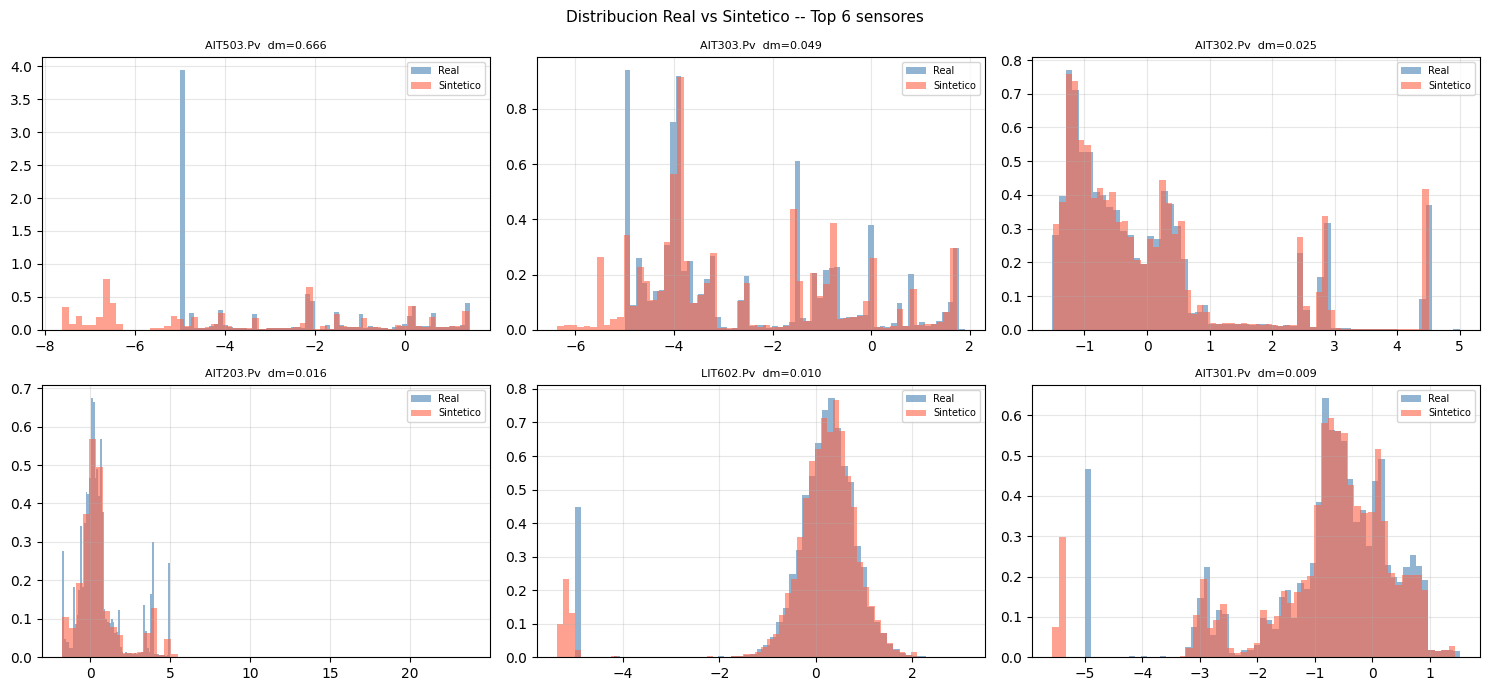

In [9]:
var_r  = X_tr_c.reshape(-1, X_tr_c.shape[2]).var(axis=0)
top6   = np.argsort(var_r)[-6:][::-1]
rf     = X_tr_c.reshape(-1, X_tr_c.shape[2])
sf     = X_sy_c.reshape(-1, X_sy_c.shape[2])
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, idx in zip(axes.flat, top6):
    nm = continuous_cols[idx]
    ax.hist(rf[:,idx], bins=60, alpha=0.6, density=True, color='steelblue', label='Real')
    ax.hist(sf[:,idx], bins=60, alpha=0.6, density=True, color='tomato',    label='Sintetico')
    dm = abs(rf[:,idx].mean() - sf[:,idx].mean())
    ax.set_title(f'{nm}  dm={dm:.3f}', fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('Distribucion Real vs Sintetico -- Top 6 sensores', fontsize=11)
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'dist_real_vs_synth.png'), dpi=120, bbox_inches='tight')
plt.show()


## 6. Arquitectura (identica a baseline v6)

In [10]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, c0))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * (mse_c + beta * kl) + (1 - alpha) * mse_d, mse_c, mse_d, kl

model = HybridLSTMVAE(
    cont_size   = X_tr_c.shape[2],
    seq_len     = WINDOW_SIZE,
    disc_dim    = X_tr_d.shape[1],
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales : {n_params:,}')
print(f'  Encoder LSTM     : {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM     : {sum(p.numel() for p in model.decoder_cont.parameters()):,}')
print(f'  Encoder disc     : {sum(p.numel() for p in model.encoder_disc.parameters()):,}')
print(f'  Decoder disc     : {sum(p.numel() for p in model.decoder_disc.parameters()):,}')


Parametros totales : 818,235
  Encoder LSTM     : 361,728
  Decoder LSTM     : 436,255
  Encoder disc     : 10,080
  Decoder disc     : 10,172


## 7. Funciones de entrenamiento y evaluacion

In [11]:
def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha*(mse_c + beta*kl) + (1-alpha)*mse_d, mse_c, mse_d, kl

def build_model():
    return HybridLSTMVAE(
        cont_size=X_tr_c.shape[2], seq_len=WINDOW_SIZE,
        disc_dim=X_tr_d.shape[1],  hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,     latent_dim=LATENT_DIM,
        disc_hidden=DISC_HIDDEN,   dropout=DROPOUT
    ).to(device)

def train_model(Xc_train, Xd_train, label):
    """Val siempre = X_va_c / X_va_d (A11_val + A12_val)."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = build_model()
    tr_loader = DataLoader(
        TensorDataset(torch.tensor(Xc_train, dtype=torch.float32),
                      torch.tensor(Xd_train, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    va_loader = DataLoader(
        TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                      torch.tensor(X_va_d, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)
    opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched= torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',factor=0.5,patience=10,min_lr=1e-6)
    best_val = float('inf'); best_wts = None; no_imp = 0; best_ep = 1
    tr_hist = []; va_hist = []
    print(f'\n[{label}] {len(Xc_train):,} train | {len(X_va_c):,} val | batch={BATCH_SIZE}')
    for ep in range(1, MAX_EPOCHS+1):
        model.train()
        tl = 0.0
        for xc_b, xd_b in tr_loader:
            xc_b = xc_b.to(device); xd_b = xd_b.to(device)
            opt.zero_grad()
            xc_h, xd_h, mu, lv = model(xc_b, xd_b)
            loss = elbo_loss(xc_b, xc_h, xd_b, xd_h, mu, lv, ALPHA, BETA)[0]
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tl += loss.item()
        tl /= len(tr_loader)
        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc_b, xd_b in va_loader:
                xc_b = xc_b.to(device); xd_b = xd_b.to(device)
                xc_h, xd_h, mu, lv = model(xc_b, xd_b)
                vl += elbo_loss(xc_b, xc_h, xd_b, xd_h, mu, lv, ALPHA, BETA)[0].item()
        vl /= len(va_loader)
        sched.step(vl)
        tr_hist.append(tl); va_hist.append(vl)
        if vl < best_val - 1e-6:
            best_val = vl; best_ep = ep; no_imp = 0
            best_wts = {kk: vv.clone() for kk, vv in model.state_dict().items()}
        else:
            no_imp += 1
        if ep % 20 == 0:
            print(f'  Ep {ep:4d} | Train:{tl:.5f} | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
        if no_imp >= PATIENCE:
            print(f'  Early stop ep{ep}.'); break
    model.load_state_dict(best_wts); model.eval()
    print(f'  Mejor val:{best_val:.5f} ep{best_ep}')
    return model, tr_hist, va_hist, best_ep, best_val

def recon_scores(model, Xc, Xd, alpha, bs=256):
    ldr = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                   torch.tensor(Xd, dtype=torch.float32)),
                     batch_size=bs, shuffle=False)
    ec_l = []; ed_l = []
    model.eval()
    with torch.no_grad():
        for xc_b, xd_b in ldr:
            xc_b = xc_b.to(device); xd_b = xd_b.to(device)
            xc_h, xd_h, mu, _ = model(xc_b, xd_b)
            ec_l.extend(torch.mean((xc_h-xc_b)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_h-xd_b)**2, dim=1).cpu().numpy())
    return alpha*np.array(ec_l) + (1-alpha)*np.array(ed_l)

def consec_filter(scores_arr, tau, k):
    raw = (scores_arr > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out

def evaluate_model(model, Xev_c, Xev_d, y_ev, df_ev, excl_ids, k_consec):
    """Evalua un modelo. Todos los datos se pasan como parametros.
    No depende de variables globales de datos."""
    sc = recon_scores(model, Xev_c, Xev_d, ALPHA)
    assert len(sc) == len(y_ev), f'ERROR: scores={len(sc)} != y_ev={len(y_ev)}'
    mn = sc[y_ev==0].mean(); ma = sc[y_ev==1].mean()
    auc_ref = roc_auc_score(y_ev, sc)
    # Excluir ataques sigilosos
    keep = ~((df_ev['y'].values==1) & np.isin(df_ev['attack_id'].values, excl_ids))
    sc_f = sc[keep]
    y_f  = y_ev[keep]
    assert len(sc_f) == len(y_f), f'ERROR filtrado: sc_f={len(sc_f)} != y_f={len(y_f)}'
    # Sweep tau
    taus = np.percentile(sc_f, np.linspace(0.5, 99.5, 800))
    bf1 = -1.0; btau = float(taus[0])
    for tau in taus:
        pr = consec_filter(sc_f, tau, k_consec)
        tp_ = int(((pr==1)&(y_f==1)).sum()); fp_ = int(((pr==1)&(y_f==0)).sum())
        fn_ = int(((pr==0)&(y_f==1)).sum()); tn_ = int(((pr==0)&(y_f==0)).sum())
        pp = tp_/(tp_+fp_+1e-10); rr = tp_/(tp_+fn_+1e-10)
        ff = 2*pp*rr/(pp+rr+1e-10)
        if ff > bf1: bf1 = ff; btau = float(tau)
    # Metricas finales
    pr_f = consec_filter(sc_f, btau, k_consec)
    tp = int(((pr_f==1)&(y_f==1)).sum())
    fp = int(((pr_f==1)&(y_f==0)).sum())
    fn = int(((pr_f==0)&(y_f==1)).sum())
    tn = int(((pr_f==0)&(y_f==0)).sum())
    prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
    f1   = 2*prec*rec/(prec+rec+1e-10)
    fpr  = fp/(fp+tn+1e-10)
    return {
        'tau': btau, 'roc_auc': float(roc_auc_score(y_f, sc_f)),
        'roc_auc_ref': float(auc_ref),
        'pr_auc': float(average_precision_score(y_f, sc_f)),
        'f1': float(f1), 'recall': float(rec),
        'precision': float(prec), 'fpr': float(fpr),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'ratio': float(ma/mn) if mn > 0 else 0.0,
        'sc_all': sc, 'sc_filt': sc_f, 'y_filt': y_f,
        'keep_mask': keep,
    }

print('Funciones definidas: elbo_loss, build_model, train_model, '
      'recon_scores, consec_filter, evaluate_model')


Funciones definidas: elbo_loss, build_model, train_model, recon_scores, consec_filter, evaluate_model


## 8. Ventanas de evaluacion A12 completo

In [12]:
# Cargar A12 completo (con ataques) para evaluacion externa
df_a12_full = pd.read_csv(RAW_CSV_A12, low_memory=False)
df_a12_full['t_stamp']      = pd.to_datetime(df_a12_full['t_stamp'], errors='coerce')
df_a12_full['attack_label'] = pd.to_numeric(df_a12_full['attack_label'], errors='coerce').fillna(0).astype(int)
df_a12_full = df_a12_full.sort_values('t_stamp').reset_index(drop=True)

for col in all_sensor_cols:
    if col in df_a12_full.columns:
        df_a12_full[col] = pd.to_numeric(
            df_a12_full[col].replace('Bad Input', np.nan), errors='coerce'
        )

meta_cols_avail = [c for c in ['attack_id','attack_name','attack_targets'] if c in df_a12_full.columns]
df_a12_full[all_sensor_cols] = df_a12_full[all_sensor_cols].fillna(modes_train)

# Escalar con scaler nuevo (A11+A12)
df_eval_sc = df_a12_full[['t_stamp','attack_label'] + all_sensor_cols].copy()
df_eval_sc[continuous_cols] = np.clip(
    scaler_cont.transform(df_eval_sc[continuous_cols].values), -CLIP_VAL, CLIP_VAL
)
df_eval_sc[discrete_cols] = (df_eval_sc[discrete_cols] / disc_max).clip(0, 1)

# Arrays
cont_arr   = df_eval_sc[continuous_cols].values.astype(np.float32)
disc_arr   = df_eval_sc[discrete_cols].values.astype(np.float32)
labs_arr   = df_eval_sc['attack_label'].values
tstamp_arr = df_eval_sc['t_stamp'].values
aid_arr    = df_a12_full['attack_id'].values   if 'attack_id'   in df_a12_full.columns else np.zeros(len(df_a12_full))
aname_arr  = df_a12_full['attack_name'].values if 'attack_name' in df_a12_full.columns else np.full(len(df_a12_full),'unknown')

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]
    atk_ids  = seg_aids[seg_labs==1]
    atk_nms  = seg_anms[seg_labs==1]
    if len(atk_ids) > 0:
        uid, cnt = np.unique(atk_ids, return_counts=True); aid_mode = uid[cnt.argmax()]
        unm, cnm = np.unique(atk_nms, return_counts=True); anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, 'normal'
    meta_rows.append({'y': int(np.any(seg_labs==1)), 'attack_id': aid_mode,
                      'attack_name': str(anm_mode), 't_start': tstamp_arr[s],
                      'attack_frac': float(np.mean(seg_labs==1))})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)

print(f'Ventanas eval (A12): {len(df_wins):,}')
print(f'  Normal (y=0)     : {(df_wins["y"]==0).sum():,}')
print(f'  Ataque (y=1)     : {(df_wins["y"]==1).sum():,}  ({100*df_wins["y"].mean():.1f}%)')
print(f'  Tipos de ataque  : {df_wins[df_wins["y"]==1]["attack_id"].nunique()}')

# IMPORTANTE: y_all definido aqui, siempre fresco desde df_wins
y_all = df_wins['y'].values
print(f'X_eval_c: {X_eval_c.shape} | y_all: {len(y_all)}')
assert len(X_eval_c) == len(y_all) == len(df_wins), 'Mismatch eval lengths!'


Ventanas eval (A12): 5,761
  Normal (y=0)     : 5,027
  Ataque (y=1)     : 734  (12.7%)
  Tipos de ataque  : 11
X_eval_c: (5761, 60, 31) | y_all: 5761


## 9. Escenario 1 -- real_only (identico a baseline v6)

In [13]:
m_real, h_tr_r, h_va_r, ep_r, val_r = train_model(X_tr_c, X_tr_d, 'real_only')
torch.save(m_real.state_dict(), TSTR_DIR / 'model_real_only.pt')
print('Guardado: model_real_only.pt')



[real_only] 10,009 train | 3,337 val | batch=64
  Ep   20 | Train:0.08669 | Val:0.12953 | Best:0.12953(ep20)
  Ep   40 | Train:0.07076 | Val:0.13643 | Best:0.12953(ep20)
  Early stop ep40.
  Mejor val:0.12953 ep20
Guardado: model_real_only.pt


## 10. Escenario 2 -- synthetic_only

In [14]:
m_synth, h_tr_s, h_va_s, ep_s, val_s = train_model(X_sy_c, X_sy_d, 'synthetic_only')
torch.save(m_synth.state_dict(), TSTR_DIR / 'model_synthetic_only.pt')
print('Guardado: model_synthetic_only.pt')



[synthetic_only] 10,009 train | 3,337 val | batch=64
  Ep   20 | Train:21.33159 | Val:0.32268 | Best:0.30993(ep17)
  Ep   40 | Train:11.00785 | Val:0.40181 | Best:0.25988(ep36)
  Early stop ep56.
  Mejor val:0.25988 ep36
Guardado: model_synthetic_only.pt


## 11. Escenario 3 -- real_plus_synthetic

In [15]:
X_co_c = np.concatenate([X_tr_c, X_sy_c], axis=0)
X_co_d = np.concatenate([X_tr_d, X_sy_d], axis=0)
print(f'Combined: {len(X_co_c):,} (real={len(X_tr_c):,} + synth={len(X_sy_c):,})')
print(f'Proporcion real: {100*len(X_tr_c)/len(X_co_c):.1f}%')
m_comb, h_tr_c, h_va_c, ep_c, val_c = train_model(X_co_c, X_co_d, 'real_plus_synthetic')
torch.save(m_comb.state_dict(), TSTR_DIR / 'model_real_plus_synthetic.pt')
print('Guardado: model_real_plus_synthetic.pt')


Combined: 20,018 (real=10,009 + synth=10,009)
Proporcion real: 50.0%

[real_plus_synthetic] 20,018 train | 3,337 val | batch=64
  Ep   20 | Train:7.72512 | Val:0.17808 | Best:0.10119(ep19)
  Ep   40 | Train:2.25424 | Val:0.08243 | Best:0.08243(ep40)
  Ep   60 | Train:0.79278 | Val:0.08160 | Best:0.08044(ep53)
  Early stop ep73.
  Mejor val:0.08044 ep53
Guardado: model_real_plus_synthetic.pt


## 12. Curvas de entrenamiento

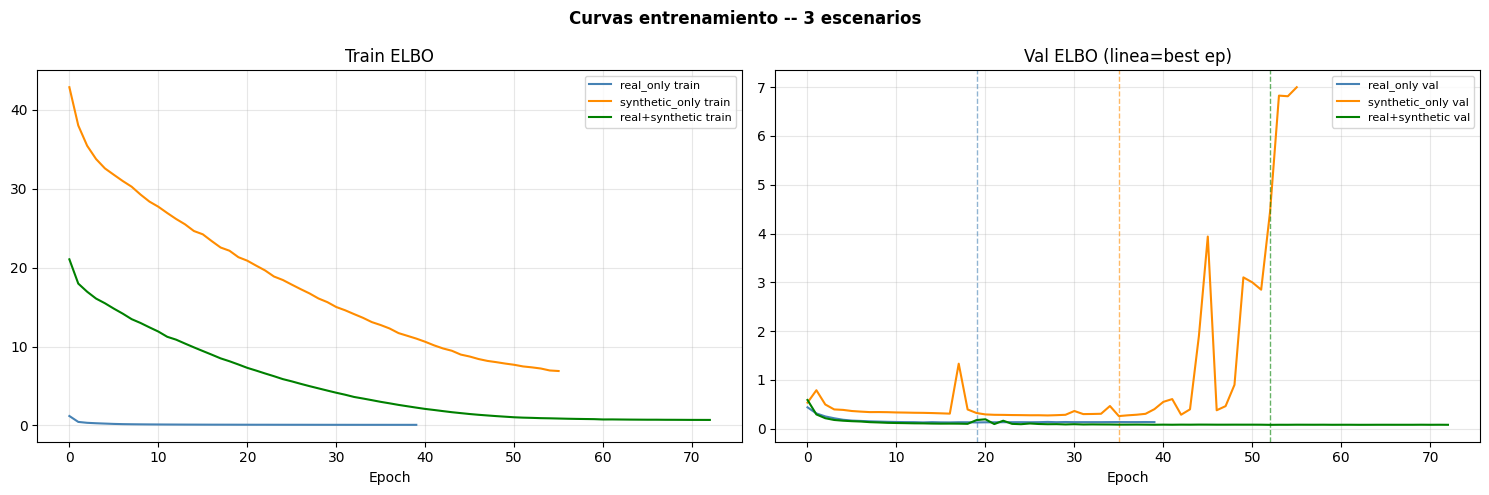

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for h_tr, h_va, ep, lbl, col in [
    (h_tr_r, h_va_r, ep_r, 'real_only',      'steelblue'),
    (h_tr_s, h_va_s, ep_s, 'synthetic_only', 'darkorange'),
    (h_tr_c, h_va_c, ep_c, 'real+synthetic', 'green'),
]:
    axes[0].plot(h_tr, lw=1.5, color=col, label=f'{lbl} train')
    axes[1].plot(h_va, lw=1.5, color=col, label=f'{lbl} val')
    axes[1].axvline(ep-1, color=col, lw=1, linestyle='--', alpha=0.6)
for ax, ttl in zip(axes, ['Train ELBO', 'Val ELBO (linea=best ep)']):
    ax.set_title(ttl); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Curvas entrenamiento -- 3 escenarios', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


## 13. Cargar modelos del disco y evaluar

Los modelos se recargan del disco para garantizar estado limpio.
La funcion `evaluate_model` recibe todos los datos como parametros
para evitar dependencias de variables globales.


In [17]:
# Recargar modelos del disco
m_real_ev = build_model()
m_real_ev.load_state_dict(torch.load(TSTR_DIR / 'model_real_only.pt', map_location=device))
m_real_ev.eval()

m_synth_ev = build_model()
m_synth_ev.load_state_dict(torch.load(TSTR_DIR / 'model_synthetic_only.pt', map_location=device))
m_synth_ev.eval()

m_comb_ev = build_model()
m_comb_ev.load_state_dict(torch.load(TSTR_DIR / 'model_real_plus_synthetic.pt', map_location=device))
m_comb_ev.eval()

print('Modelos recargados del disco OK')
print(f'Datos eval: X_eval_c={X_eval_c.shape} | y_all={len(y_all)} | df_wins={len(df_wins)}')
assert len(X_eval_c) == len(y_all) == len(df_wins)


Modelos recargados del disco OK
Datos eval: X_eval_c=(5761, 60, 31) | y_all=5761 | df_wins=5761


In [18]:
R_KEYS = ['real_only', 'synthetic_only', 'real_plus_synthetic']
RES = {}

print(f'Evaluando (excl. IDs {EXCLUDED_IDS} | k={CONSEC_K} | sweep 800 taus)\n')
for mdl, lbl in [
    (m_real_ev,  'real_only'),
    (m_synth_ev, 'synthetic_only'),
    (m_comb_ev,  'real_plus_synthetic'),
]:
    RES[lbl] = evaluate_model(mdl, X_eval_c, X_eval_d, y_all, df_wins, EXCLUDED_IDS, CONSEC_K)
    r = RES[lbl]
    print(f'  [{lbl}] AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | '
          f'Rec={r["recall"]:.3f} | Prec={r["precision"]:.3f} | FPR={r["fpr"]:.3f}')


Evaluando (excl. IDs [1.0, 2.0] | k=13 | sweep 800 taus)

  [real_only] AUC=0.8737 | F1=0.485 | Rec=0.887 | Prec=0.333 | FPR=0.209
  [synthetic_only] AUC=0.6014 | F1=0.249 | Rec=0.593 | Prec=0.157 | FPR=0.374
  [real_plus_synthetic] AUC=0.7618 | F1=0.357 | Rec=0.341 | Prec=0.375 | FPR=0.067


## 14. Tabla comparativa

In [19]:
n_wins = {
    'real_only': len(X_tr_c),
    'synthetic_only': len(X_sy_c),
    'real_plus_synthetic': len(X_co_c),
}
df_comp = pd.DataFrame([{
    'Escenario'  : lbl,
    'Train_wins' : n_wins[lbl],
    'ROC-AUC'    : round(RES[lbl]['roc_auc'], 4),
    'PR-AUC'     : round(RES[lbl]['pr_auc'],  4),
    'F1'         : round(RES[lbl]['f1'],       3),
    'Recall'     : round(RES[lbl]['recall'],   3),
    'Precision'  : round(RES[lbl]['precision'],3),
    'FPR'        : round(RES[lbl]['fpr'],      3),
    'TP'         : RES[lbl]['tp'],
    'FP'         : RES[lbl]['fp'],
    'FN'         : RES[lbl]['fn'],
} for lbl in R_KEYS])
print(df_comp.to_string(index=False))
print()
base = RES['real_only']
print('Delta vs real_only:')
for lbl in ['synthetic_only', 'real_plus_synthetic']:
    r = RES[lbl]
    print(f'  {lbl:<25}: DAUC={r["roc_auc"]-base["roc_auc"]:+.4f} | '
          f'DF1={r["f1"]-base["f1"]:+.3f} | DRec={r["recall"]-base["recall"]:+.3f} | '
          f'DFPR={r["fpr"]-base["fpr"]:+.3f}')
df_comp.to_csv(TSTR_DIR / 'tabla_comparativa.csv', index=False)


          Escenario  Train_wins  ROC-AUC  PR-AUC    F1  Recall  Precision   FPR  TP   FP  FN
          real_only       10009   0.8737  0.3166 0.485   0.887      0.333 0.209 525 1050  67
     synthetic_only       10009   0.6014  0.1682 0.249   0.593      0.157 0.374 351 1879 241
real_plus_synthetic       20018   0.7618  0.2620 0.357   0.341      0.375 0.067 202  337 390

Delta vs real_only:
  synthetic_only           : DAUC=-0.2723 | DF1=-0.236 | DRec=-0.294 | DFPR=+0.165
  real_plus_synthetic      : DAUC=-0.1119 | DF1=-0.127 | DRec=-0.546 | DFPR=-0.142


## 15. Graficos comparativos

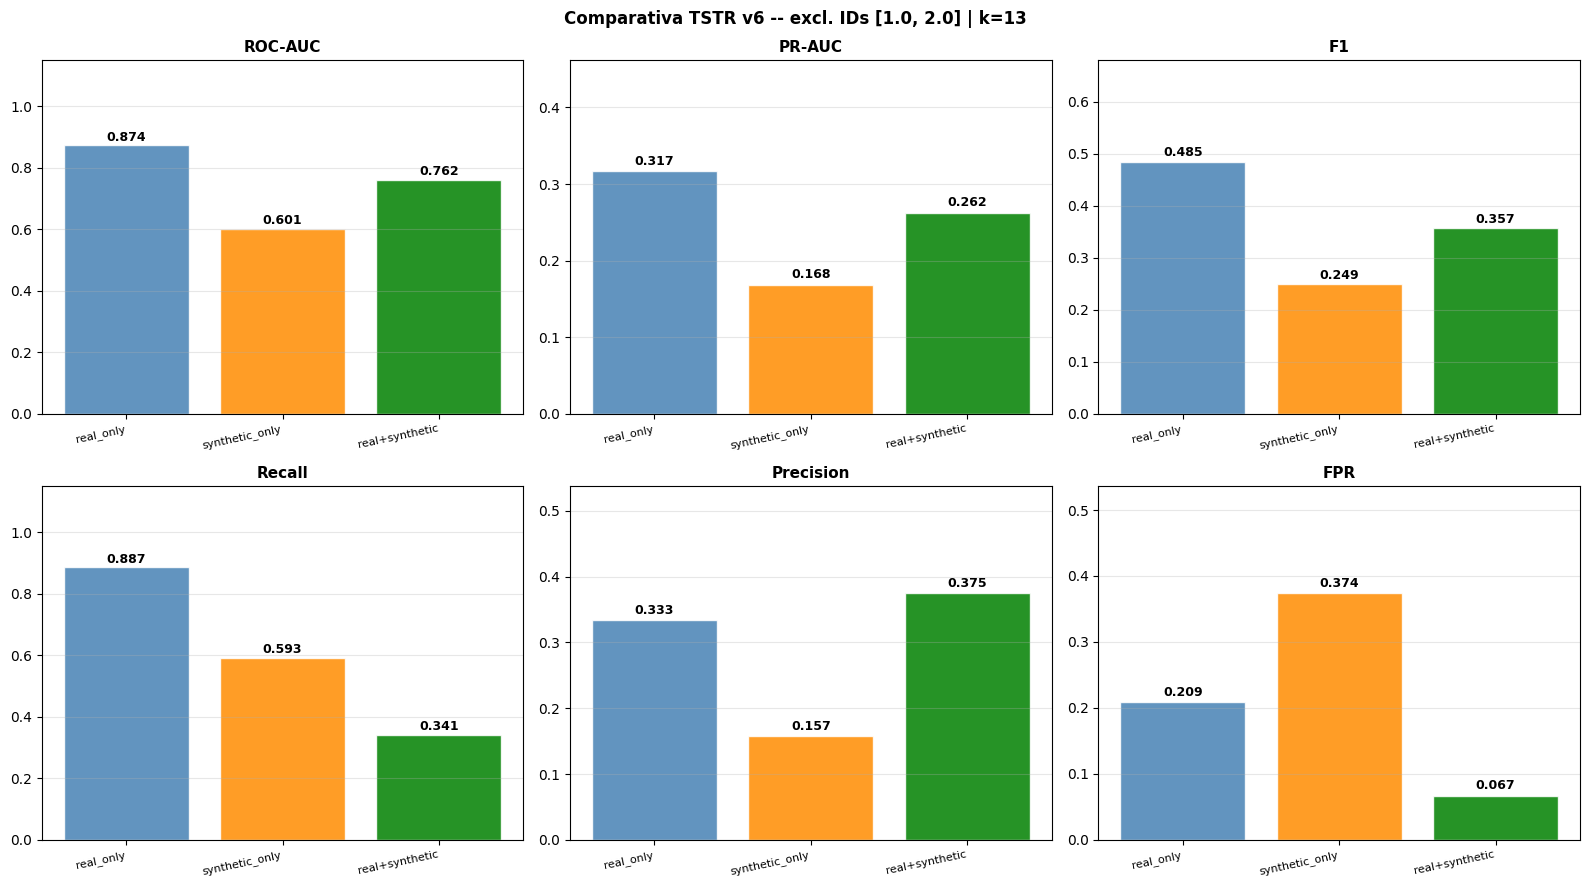

In [20]:
colors_sc = ['steelblue', 'darkorange', 'green']
labels_sc  = ['real_only', 'synthetic_only', 'real+synthetic']
met_keys   = ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision', 'fpr']
met_labels = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision', 'FPR']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, mk, ml in zip(axes.flat, met_keys, met_labels):
    vals = [RES[lbl][mk] for lbl in R_KEYS]
    bars = ax.bar(labels_sc, vals, color=colors_sc, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(ml, fontsize=11, fontweight='bold')
    ax.set_ylim(0, min(1.15, max(vals)*1.3+0.05))
    ax.set_xticklabels(labels_sc, rotation=12, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle(f'Comparativa TSTR v6 -- excl. IDs {EXCLUDED_IDS} | k={CONSEC_K}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'metricas_comparativas.png'), dpi=130, bbox_inches='tight')
plt.show()


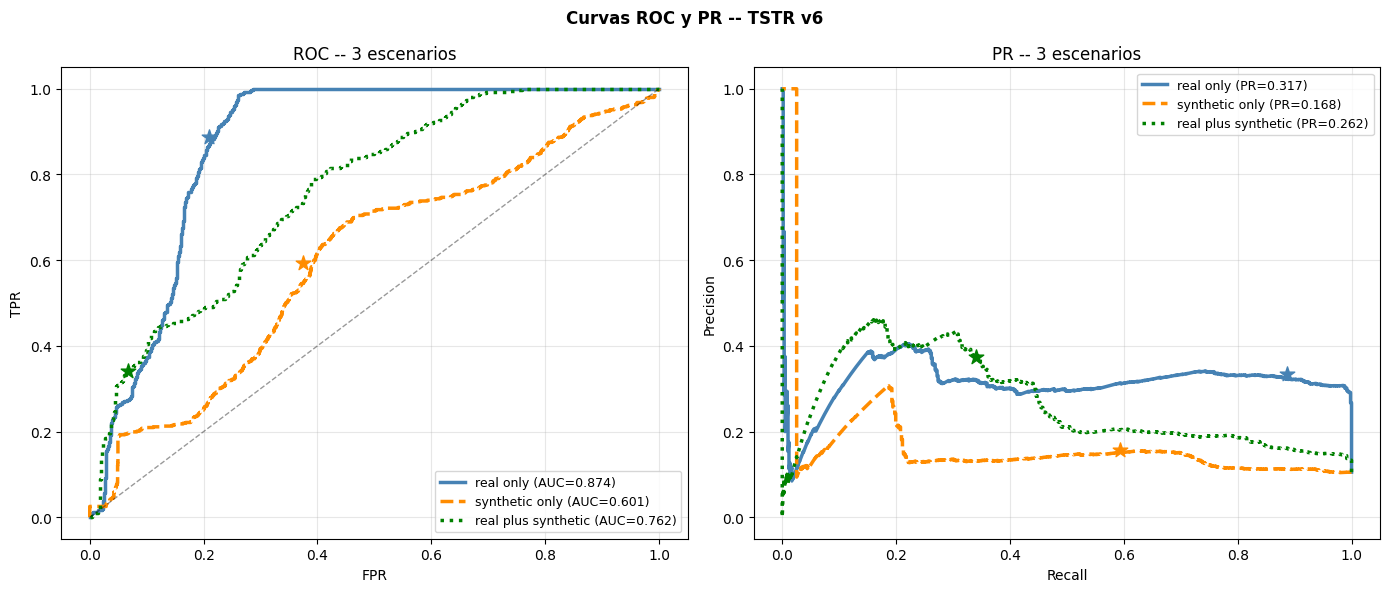

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for lbl, col, sty in zip(R_KEYS, colors_sc, ['-', '--', ':']):
    r = RES[lbl]
    fp_, tp_, _ = roc_curve(r['y_filt'], r['sc_filt'])
    pr_, re_, _ = precision_recall_curve(r['y_filt'], r['sc_filt'])
    axes[0].plot(fp_, tp_, lw=2.5, color=col, linestyle=sty,
                 label=f'{lbl.replace("_"," ")} (AUC={r["roc_auc"]:.3f})')
    axes[0].scatter(r['fpr'], r['recall'], s=120, color=col, zorder=5, marker='*')
    axes[1].plot(re_, pr_, lw=2.5, color=col, linestyle=sty,
                 label=f'{lbl.replace("_"," ")} (PR={r["pr_auc"]:.3f})')
    axes[1].scatter(r['recall'], r['precision'], s=120, color=col, zorder=5, marker='*')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC -- 3 escenarios'); axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.3)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR -- 3 escenarios'); axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3)
plt.suptitle('Curvas ROC y PR -- TSTR v6', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'roc_pr_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()


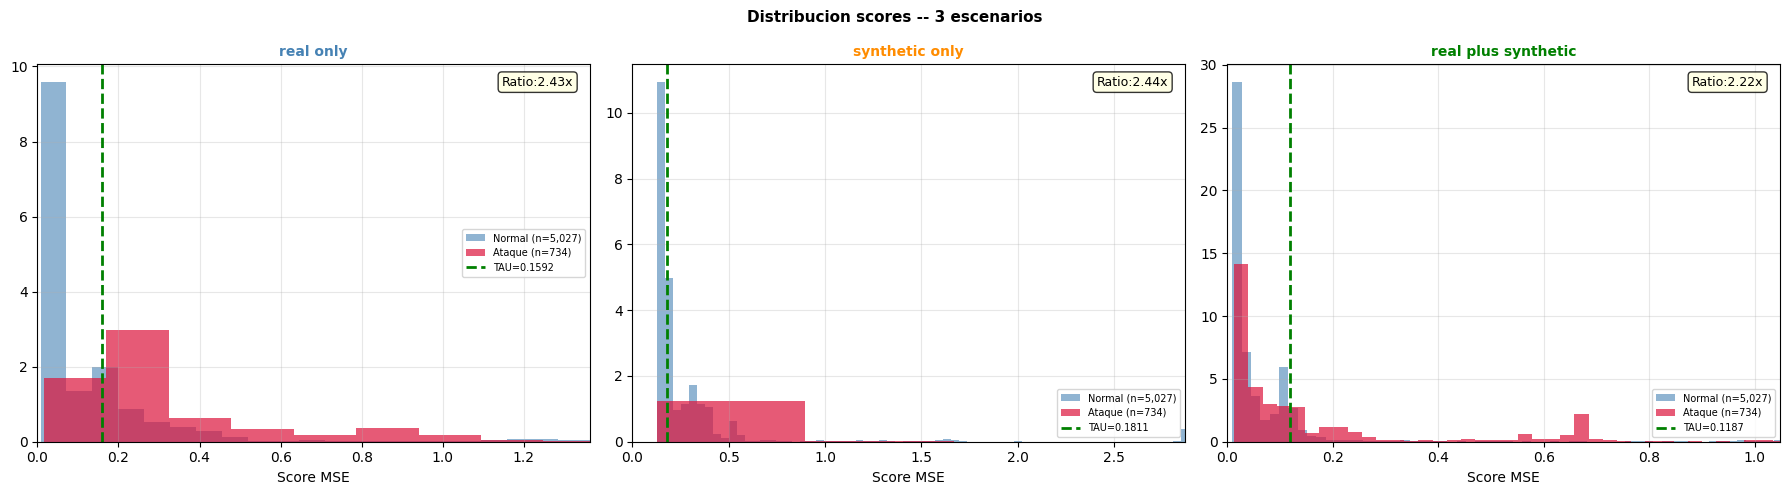

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl, col in zip(axes, R_KEYS, colors_sc):
    sc = RES[lbl]['sc_all']
    ax.hist(sc[y_all==0], bins=80, alpha=0.6, density=True, color='steelblue',
            label=f'Normal (n={(y_all==0).sum():,})')
    ax.hist(sc[y_all==1], bins=40, alpha=0.7, density=True, color='crimson',
            label=f'Ataque (n={(y_all==1).sum():,})')
    ax.axvline(RES[lbl]['tau'], color='green', lw=2, linestyle='--',
               label=f'TAU={RES[lbl]["tau"]:.4f}')
    ax.text(0.97, 0.97, f'Ratio:{RES[lbl]["ratio"]:.2f}x', ha='right', va='top',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)
    ax.set_title(lbl.replace('_',' '), fontsize=10, fontweight='bold', color=col)
    ax.set_xlabel('Score MSE'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, np.percentile(sc, 99.5))
plt.suptitle('Distribucion scores -- 3 escenarios', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


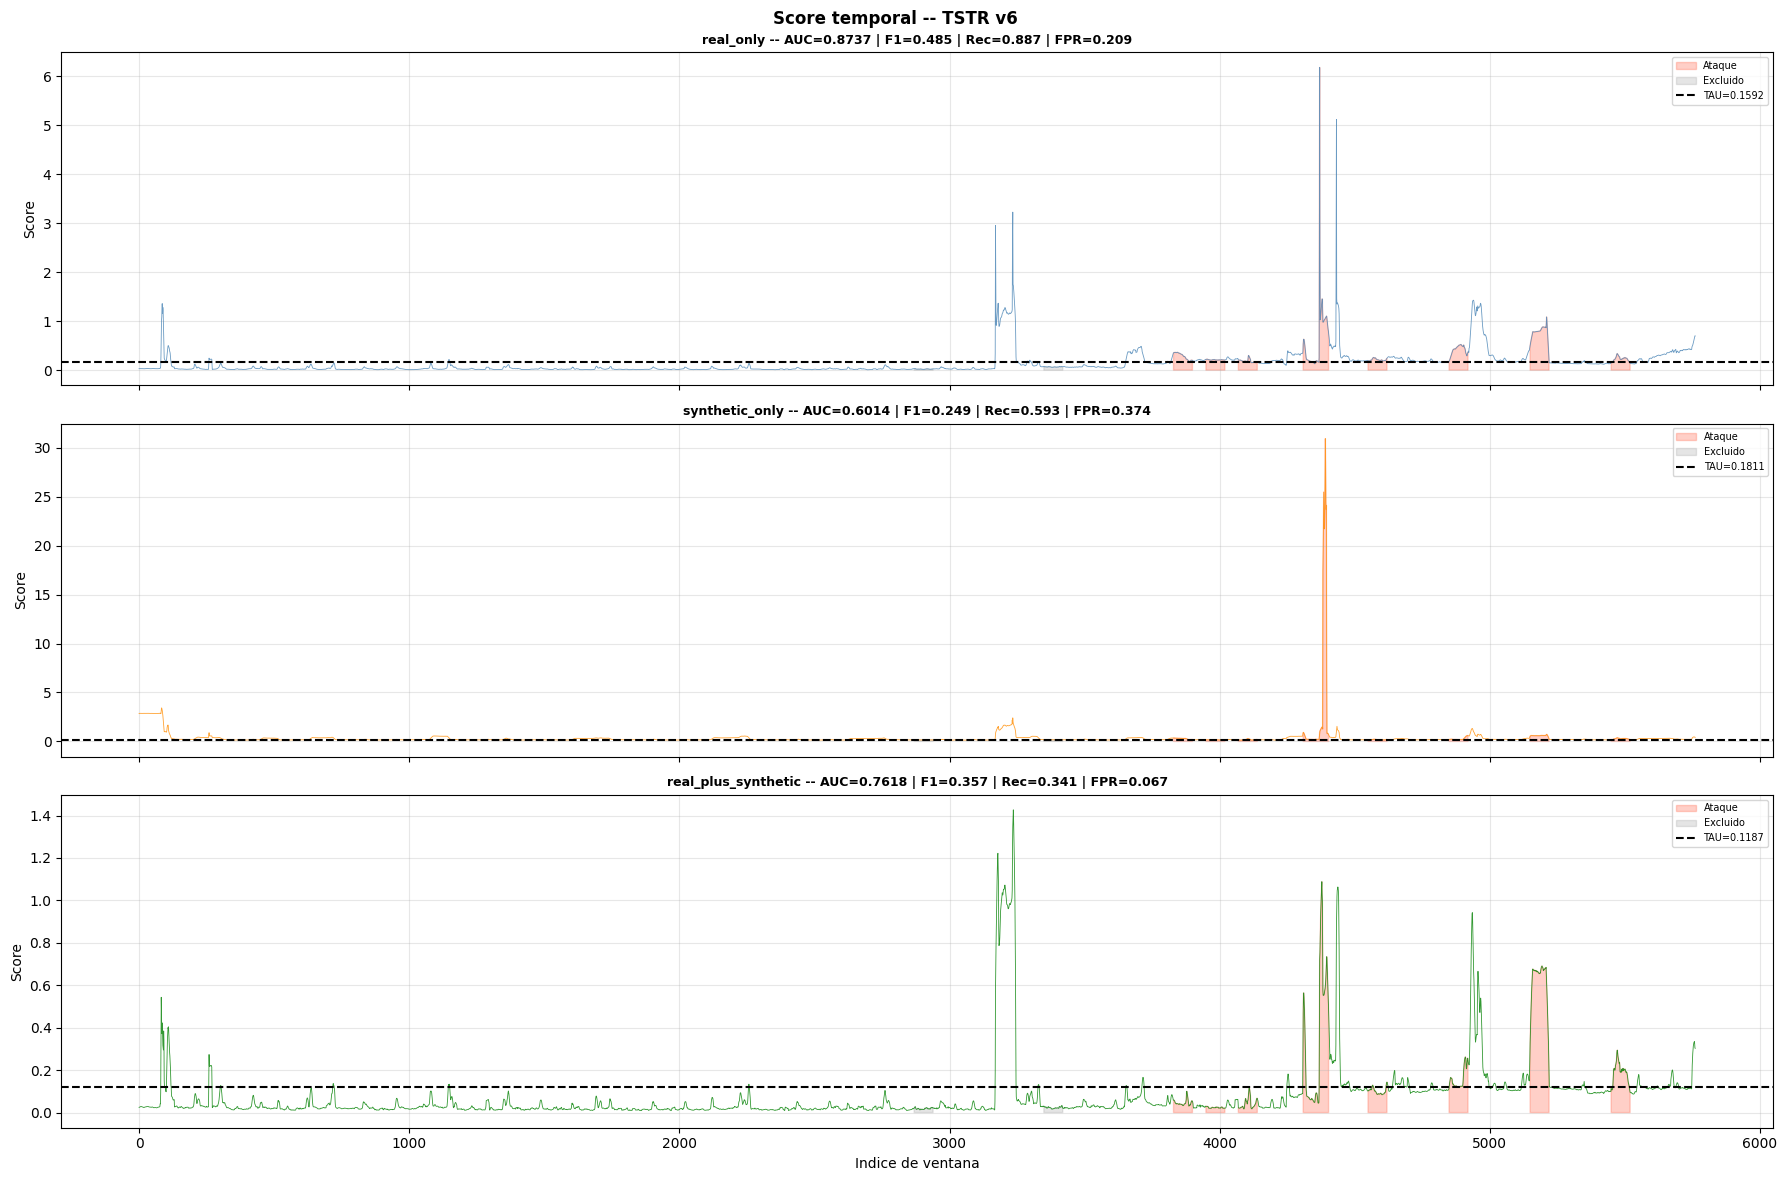

In [23]:
t_idx = np.arange(len(df_wins))
excl_mask = np.isin(df_wins['attack_id'].values, EXCLUDED_IDS) & (y_all==1)
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for ax, lbl, col in zip(axes, R_KEYS, colors_sc):
    sc = RES[lbl]['sc_all']
    ax.plot(t_idx, sc, color=col, lw=0.6, alpha=0.8)
    ax.fill_between(t_idx, 0, sc, where=(y_all==1)&~excl_mask,
                    color='tomato', alpha=0.30, label='Ataque')
    ax.fill_between(t_idx, 0, sc, where=excl_mask,
                    color='gray',  alpha=0.20, label='Excluido')
    ax.axhline(RES[lbl]['tau'], color='black', lw=1.5, linestyle='--',
               label=f'TAU={RES[lbl]["tau"]:.4f}')
    r = RES[lbl]
    ax.set_title(f'{lbl} -- AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | '
                 f'Rec={r["recall"]:.3f} | FPR={r["fpr"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Score'); ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Indice de ventana')
plt.suptitle('Score temporal -- TSTR v6', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'score_temporal.png'), dpi=130, bbox_inches='tight')
plt.show()


 attack_id                         nombre  n  det_real_only  det_synthetic_only  det_real_plus_synthetic  excluido
       1.0 Stage 5 Valve Manipulation — M 71            0.0                 0.0                      0.0      True
       2.0 Stage 1 Flow Disruption — MV10 71            0.0                 0.0                      0.0      True
       3.0 Florida Water Plant Scenario — 71           83.1                62.0                      0.0     False
       4.0 Tank Overflow via LIT101 Spoof 71           83.1                 0.0                      0.0     False
       5.0 Stage 5 Valve Manipulation — M 71           49.3                 8.5                      0.0     False
       6.0 Tank Overflow via LIT101 Spoof 30           60.0                60.0                      0.0     False
       7.0 Stage 2 Parallel Pump Override 65           56.9                81.5                     35.4     False
       8.0 Reverse Osmosis Backwash Diver 71           83.1                 5.6 

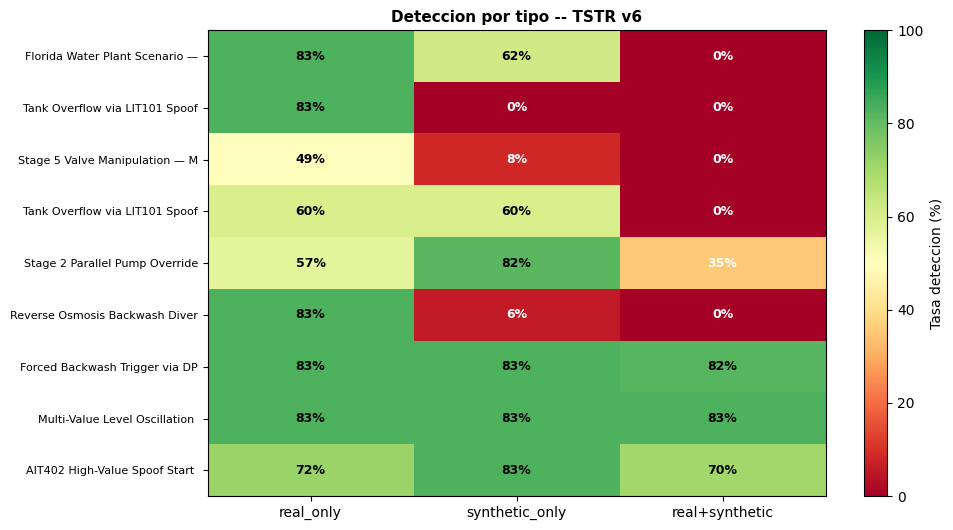

In [24]:
atk_ids_u = sorted(df_wins[df_wins['y']==1]['attack_id'].unique())
det_rows = []
for aid in atk_ids_u:
    grp = df_wins[df_wins['attack_id']==aid]
    n_t  = len(grp)
    nm   = grp['attack_name'].mode().iloc[0][:30]
    excl = bool(np.isin(aid, EXCLUDED_IDS))
    row  = {'attack_id': aid, 'nombre': nm, 'n': n_t, 'excluido': excl}
    for lbl in R_KEYS:
        sc_g = RES[lbl]['sc_all'][df_wins['attack_id']==aid]
        pg   = consec_filter(sc_g, RES[lbl]['tau'], CONSEC_K)
        row[f'det_{lbl}'] = round(100*pg.sum()/n_t, 1) if n_t>0 else 0.0
    det_rows.append(row)
df_det = pd.DataFrame(det_rows)
print(df_det[['attack_id','nombre','n','det_real_only',
              'det_synthetic_only','det_real_plus_synthetic','excluido']].to_string(index=False))
df_heat = df_det[~df_det['excluido']].set_index('nombre')
heat = df_heat[['det_real_only','det_synthetic_only','det_real_plus_synthetic']].values
fig, ax = plt.subplots(figsize=(10, max(4, len(df_heat)*0.6)))
im = ax.imshow(heat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['real_only','synthetic_only','real+synthetic'], fontsize=10)
ax.set_yticks(range(len(df_heat))); ax.set_yticklabels(df_heat.index.tolist(), fontsize=8)
for ii in range(len(df_heat)):
    for jj in range(3):
        ax.text(jj, ii, f'{heat[ii,jj]:.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if heat[ii,jj]<40 else 'black')
plt.colorbar(im, ax=ax, label='Tasa deteccion (%)')
ax.set_title('Deteccion por tipo -- TSTR v6', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TSTR_DIR / 'deteccion_heatmap.png'), dpi=130, bbox_inches='tight')
plt.show()
df_det.to_csv(TSTR_DIR / 'deteccion_por_tipo.csv', index=False)


## 16. Guardar resultados

In [25]:
tstr_cfg = {
    'version': 'lstm_vae_tstr_v6',
    'baseline': 'lstm_vae_a12_baseline_v6',
    'timegan': 'lstm_vae_a12_baseline_v1_v18',
    'eval_protocol': {'excluded_ids': EXCLUDED_IDS, 'k': CONSEC_K},
    'train_windows': {
        'real_only': len(X_tr_c),
        'synthetic_only': len(X_sy_c),
        'real_plus_synthetic': len(X_co_c),
    },
    'best_epochs': {'real_only': ep_r, 'synthetic_only': ep_s, 'real_plus_synthetic': ep_c},
    'results': {
        lbl: {mk: RES[lbl][mk] for mk in
              ['tau','roc_auc','pr_auc','f1','recall','precision','fpr','tp','fp','fn','tn','ratio']}
        for lbl in R_KEYS
    },
    'delta_vs_real_only': {
        lbl: {
            'delta_auc': round(RES[lbl]['roc_auc']-RES['real_only']['roc_auc'], 4),
            'delta_f1':  round(RES[lbl]['f1']-RES['real_only']['f1'],  3),
            'delta_rec': round(RES[lbl]['recall']-RES['real_only']['recall'], 3),
            'delta_fpr': round(RES[lbl]['fpr']-RES['real_only']['fpr'],  3),
        } for lbl in ['synthetic_only', 'real_plus_synthetic']
    },
}
with open(TSTR_DIR / 'tstr_results.json', 'w') as out_f:
    json.dump(tstr_cfg, out_f, indent=4)
print('Guardado en:', TSTR_DIR)
print()
print('='*70)
print('RESUMEN FINAL -- TSTR v6')
print('='*70)
for lbl in R_KEYS:
    r = RES[lbl]
    print(f'  {lbl:<25}: AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.3f} | '
          f'Rec={r["recall"]:.3f} | Prec={r["precision"]:.3f} | FPR={r["fpr"]:.3f}')
print()
d = tstr_cfg['delta_vs_real_only']['real_plus_synthetic']
print(f'  Delta real+synth vs real_only: DAUC={d["delta_auc"]:+.4f} | DF1={d["delta_f1"]:+.3f}')
print('='*70)


Guardado en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_tstr_v6

RESUMEN FINAL -- TSTR v6
  real_only                : AUC=0.8737 | F1=0.485 | Rec=0.887 | Prec=0.333 | FPR=0.209
  synthetic_only           : AUC=0.6014 | F1=0.249 | Rec=0.593 | Prec=0.157 | FPR=0.374
  real_plus_synthetic      : AUC=0.7618 | F1=0.357 | Rec=0.341 | Prec=0.375 | FPR=0.067

  Delta real+synth vs real_only: DAUC=-0.1119 | DF1=-0.127
